In [11]:
# install dependencies
!pip install -q --disable-pip-version-check awswrangler pyathena
!pip install -q --upgrade boto3 botocore awscli
!pip install -q librosa soundfile audioread

In [1]:
import boto3
import sagemaker
import pandas as pd
import awswrangler as wr
from pyathena import connect
import math
import os
import re
from pathlib import Path
import numpy as np
import pandas as pd
import librosa
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from datasets import load_dataset

In [2]:
# Folder initialization

# store zip file and extract data
HOME = Path().resolve()
ZIP_LOCAL = HOME / "datasets" / "zips" / "CREMAD.zip"
DATA_ROOT = HOME / "datasets" / "CREMAD"
AUDIO_DIR = DATA_ROOT / "AudioWAV"

ARTIFACTS_DIR = HOME / "artifacts" 

# confirm folders exist
ZIP_LOCAL.parent.mkdir(parents=True, exist_ok=True)
DATA_ROOT.mkdir(parents=True, exist_ok=True)

### S3 download dataset file

In [3]:
# define dataset in s3 (not accessible publicly)
S3_ZIP = "s3://ser-multilingual-spr2026msaai540-group2/CREMAD.zip"
download_from_s3 = False

# download dataset from s3
if download_from_s3:
    # download zip if needed
    print("Checking for files at :", str(ZIP_LOCAL) )

    if not ZIP_LOCAL.exists():
        !aws s3 cp {S3_ZIP} {str(ZIP_LOCAL)}
    else:
        print(f"Zip already exists: {ZIP_LOCAL}")


    # unzip if AudioWav doesn't exist
    if not AUDIO_DIR.exists() or len(list(AUDIO_DIR.glob("*.wav"))) == 0:
        !unzip -q {str(ZIP_LOCAL)} -d {str(DATA_ROOT)}
    else:
        print(f"Audio already extracted: {AUDIO_DIR} (wav files found)")

    print("AUDIO_DIR =", str(AUDIO_DIR))

## File Processing

In [4]:
def extract_comprehensive_features(file_path):
    """Extract comprehensive audio features for emotion recognition"""
    y, sr = librosa.load(file_path, sr=None)
    y_trimmed, _ = librosa.effects.trim(y, top_db=30)
    
    features = {}
    
    # Basic features
    features['duration'] = librosa.get_duration(y=y, sr=sr)
    features['rms_mean'] = np.mean(librosa.feature.rms(y=y_trimmed))
    features['zcr_mean'] = np.mean(librosa.feature.zero_crossing_rate(y_trimmed))
    
    # Spectral features
    spectral_centroid = librosa.feature.spectral_centroid(y=y_trimmed, sr=sr)
    spectral_rolloff = librosa.feature.spectral_rolloff(y=y_trimmed, sr=sr)
    spectral_bandwidth = librosa.feature.spectral_bandwidth(y=y_trimmed, sr=sr)
    spectral_contrast = librosa.feature.spectral_contrast(y=y_trimmed, sr=sr)
    
    features['spectral_centroid_mean'] = np.mean(spectral_centroid)
    features['spectral_centroid_std'] = np.std(spectral_centroid)
    features['spectral_rolloff_mean'] = np.mean(spectral_rolloff)
    features['spectral_bandwidth_mean'] = np.mean(spectral_bandwidth)
    features['spectral_contrast_mean'] = np.mean(spectral_contrast)
    
    # MFCCs (first 13 coefficients)
    mfccs = librosa.feature.mfcc(y=y_trimmed, sr=sr, n_mfcc=13)
    for i in range(13):
        features[f'mfcc_{i+1}_mean'] = np.mean(mfccs[i])
        features[f'mfcc_{i+1}_std'] = np.std(mfccs[i])
    
    # Chroma features
    chroma = librosa.feature.chroma_stft(y=y_trimmed, sr=sr)
    features['chroma_mean'] = np.mean(chroma)
    features['chroma_std'] = np.std(chroma)
    
    # Tempo and rhythm
    try:
        tempo, _ = librosa.beat.beat_track(y=y_trimmed, sr=sr)
        features['tempo'] = tempo
    except:
        features['tempo'] = 0
    
    # Pitch features
    try:
        f0, voiced_flag, voiced_probs = librosa.pyin(y_trimmed, 
                                                    fmin=librosa.note_to_hz('C2'), 
                                                    fmax=librosa.note_to_hz('C7'))
        f0_voiced = f0[voiced_flag]
        if len(f0_voiced) > 0:
            features['pitch_mean'] = np.mean(f0_voiced)
            features['pitch_std'] = np.std(f0_voiced)
            features['pitch_range'] = np.max(f0_voiced) - np.min(f0_voiced)
        else:
            features['pitch_mean'] = features['pitch_std'] = features['pitch_range'] = 0
        features['voicing_rate'] = np.sum(voiced_flag) / len(voiced_flag)
    except:
        features['pitch_mean'] = features['pitch_std'] = features['pitch_range'] = features['voicing_rate'] = 0
    
    return features

In [5]:
# create metadata from file names
AUDIO_DIR = Path(AUDIO_DIR)

# CREMA-D emotion map
EMOTION_MAP = {
    "ANG": "anger",
    "DIS": "disgust",
    "FEA": "fear",
    "HAP": "happy",
    "NEU": "neutral",
    "SAD": "sad",
}

# file name pattern
pattern = re.compile(
    r"^(?P<speaker_id>\d+)_"
    r"(?P<utterance>[A-Z]{2,4})_"
    r"(?P<emotion_code>[A-Z]{3})_"
    r"(?P<intensity>[A-Z]{1,2})"
    r"\.wav$",
    re.IGNORECASE
)

rows = []
bad = []

# extract speaker id, emotion, and utterance from audio filename
processed = 0
print(f"Processing Audio files in {AUDIO_DIR}...")

for fp in sorted(AUDIO_DIR.glob("*.wav")):
    m = pattern.match(fp.name)
    if not m:
        bad.append(fp.name)
        continue
    
    if (processed +1) % 1000 == 0:
        print(f"Processing {processed+1}/{len(rows)}")
    processed = processed + 1
      
    d = m.groupdict()
    emotion_code = d["emotion_code"].upper()

    song_features = extract_comprehensive_features(fp)

    rows.append({
        "filepath": str(fp),
        "filename": fp.name,
        "speaker_id": int(d["speaker_id"]),
        "utterance": d["utterance"].upper(),
        "emotion_code": emotion_code,
        "emotion": EMOTION_MAP.get(emotion_code, "unknown"),
        "intensity": d["intensity"].upper(),
        **song_features
    })

meta = pd.DataFrame(rows)

print("Parsed rows:", len(meta))
print("Unparsed filenames:", len(bad))
if bad:
    print("Examples of unparsed filenames:", bad[:10])

meta.head()

Processing Audio files in /Users/victorhugogermano/Development/aai-540-final-project-g2/datasets/CREMAD/AudioWAV...
Processing 1000/999
Processing 2000/1999
Processing 3000/2999
Processing 4000/3999
Processing 5000/4999
Processing 6000/5999


/opt/homebrew/anaconda3/envs/540/lib/python3.11/site-packages/librosa/core/pitch.py:103: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(


Processing 7000/6999
Parsed rows: 7442
Unparsed filenames: 0


,filepath,filename,speaker_id,utterance,emotion_code,emotion,intensity,duration,rms_mean,zcr_mean,...,mfcc_12_std,mfcc_13_mean,mfcc_13_std,chroma_mean,chroma_std,tempo,pitch_mean,pitch_std,pitch_range,voicing_rate
0,/Users/victorhugogermano/Development/aai-540-f...,1001_DFA_ANG_XX.wav,1001,DFA,ANG,anger,XX,2.275562,0.050292,0.113885,...,8.429760,-6.629968,6.810535,0.406954,0.286244,[133.92857142857142],198.731875,19.525653,55.186222,0.508475
1,/Users/victorhugogermano/Development/aai-540-f...,1001_DFA_DIS_XX.wav,1001,DFA,DIS,disgust,XX,2.335688,0.015996,0.093061,...,6.493068,-6.153906,4.568405,0.423961,0.285514,[98.6842105263158],0.000000,0.000000,0.000000,0.000000
2,/Users/victorhugogermano/Development/aai-540-f...,1001_DFA_FEA_XX.wav,1001,DFA,FEA,fear,XX,2.168813,0.101320,0.131432,...,8.014520,-4.699127,7.597995,0.335510,0.298680,[133.92857142857142],273.275620,34.388339,94.359831,0.862069
3,/Users/victorhugogermano/Development/aai-540-f...,1001_DFA_HAP_XX.wav,1001,DFA,HAP,happy,XX,1.868500,0.050926,0.092916,...,7.516437,-9.971122,6.031216,0.392220,0.302691,[117.1875],0.000000,0.000000,0.000000,0.000000
4,/Users/victorhugogermano/Development/aai-540-f...,1001_DFA_NEU_XX.wav,1001,DFA,NEU,neutral,XX,2.035375,0.020450,0.082031,...,7.823985,-3.472060,7.439857,0.401279,0.290594,[156.25],191.407180,54.101805,159.403771,0.390625


In [6]:
# saving metadata to csv
META_CSV = DATA_ROOT / "crema_d_metadata_features.csv"
meta.to_csv(META_CSV, index=False)
print(f"Metadata with features saved to {META_CSV}")


Metadata with features saved to /Users/victorhugogermano/Development/aai-540-final-project-g2/datasets/CREMAD/crema_d_metadata_features.csv


# Exploratory Data Analysis (EDA)

Here we analyze the distribution of data in our dataset (Emotions, Intensities, Speakers) and visualize the audio features (Waveforms, Spectrograms, MFCCs).

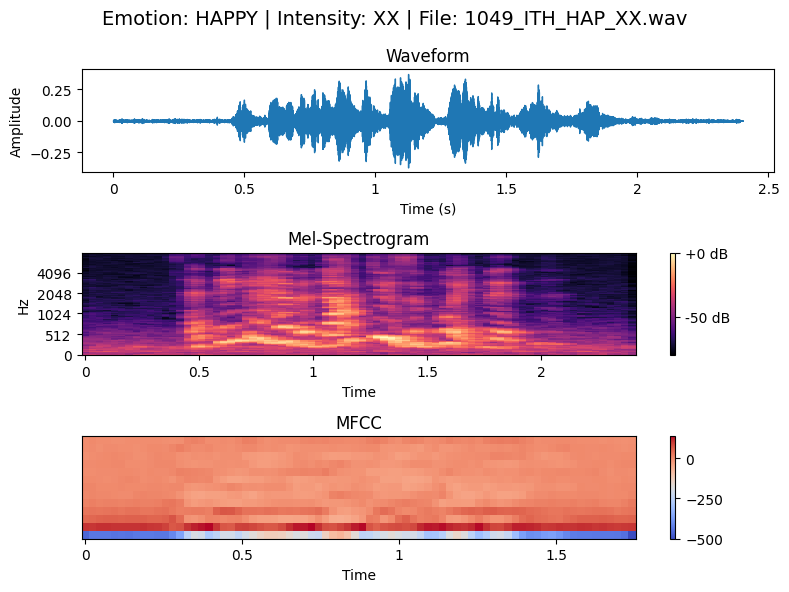

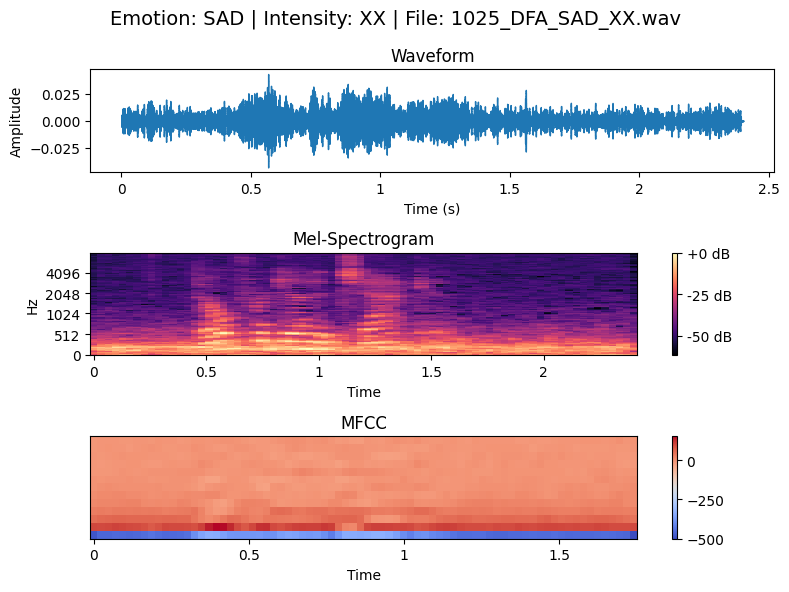

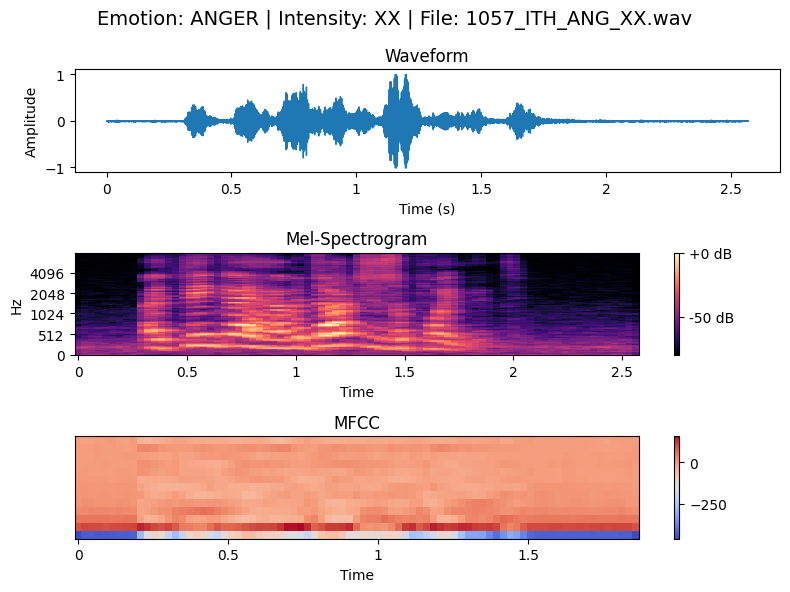

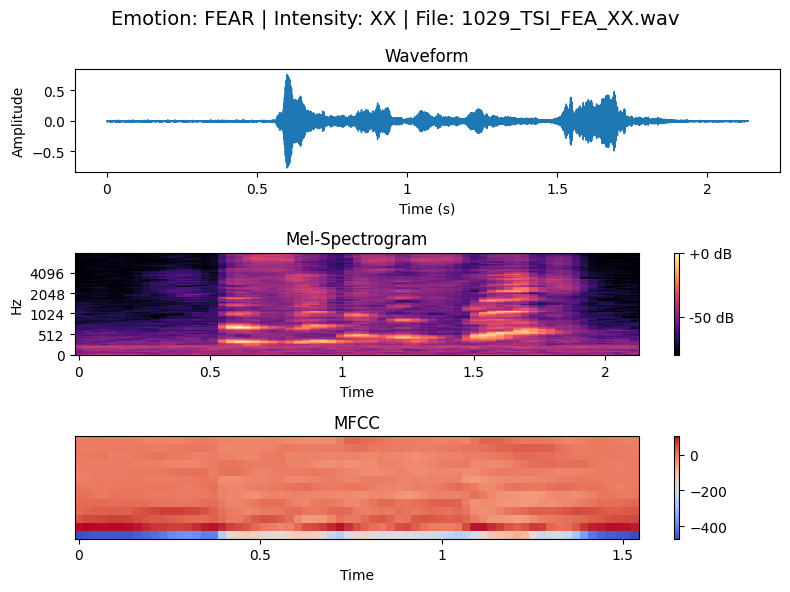

In [16]:
def plot_audio_features(row):
    filepath = row['filepath']
    emotion_label = row['emotion']
    intensity = row['intensity']

    # Load audio
    # Using sr=None to preserve native sampling rate
    y, sr = librosa.load(filepath, sr=None)
    
    # Plot
    fig, ax = plt.subplots(3, 1, figsize=(8, 6))
    fig.suptitle(f"Emotion: {emotion_label.upper()} | Intensity: {intensity} | File: {row['filename']}", fontsize=14)
    
    # Waveform
    librosa.display.waveshow(y, sr=sr, ax=ax[0])
    ax[0].set_title("Waveform")
    ax[0].set_xlabel("Time (s)")
    ax[0].set_ylabel("Amplitude")
    
    # Mel Spectrogram
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=8000)
    S_dB = librosa.power_to_db(S, ref=np.max)
    img = librosa.display.specshow(S_dB, x_axis='time', y_axis='mel', sr=sr, fmax=8000, ax=ax[1])
    fig.colorbar(img, ax=ax[1], format='%+2.0f dB')
    ax[1].set_title("Mel-Spectrogram")
    
    # MFCC
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    img2 = librosa.display.specshow(mfcc, x_axis='time', ax=ax[2])
    fig.colorbar(img2, ax=ax[2])
    ax[2].set_title("MFCC")
    
    plt.tight_layout()
    plt.show()
    
# Visualize a few samples from different emotions
emotions_to_show = ['happy', 'sad', 'anger', 'fear']
# Check if we have these emotions in the dataset to avoid errors
existing_emotions = set(meta['emotion'].unique())
emotions_to_plot = [e for e in emotions_to_show if e in existing_emotions]

for emo in emotions_to_plot:
    # Get a random sample for this emotion
    sample = meta[meta['emotion'] == emo].sample(1).iloc[0]
    plot_audio_features(sample)

### Audio Feature Visualization
Visualizing Waveforms, Mel-Spectrograms, and MFCCs to understand the acoustic features of different emotions.

Total Speakers: 91
Min clips per speaker: 76
Max clips per speaker: 82


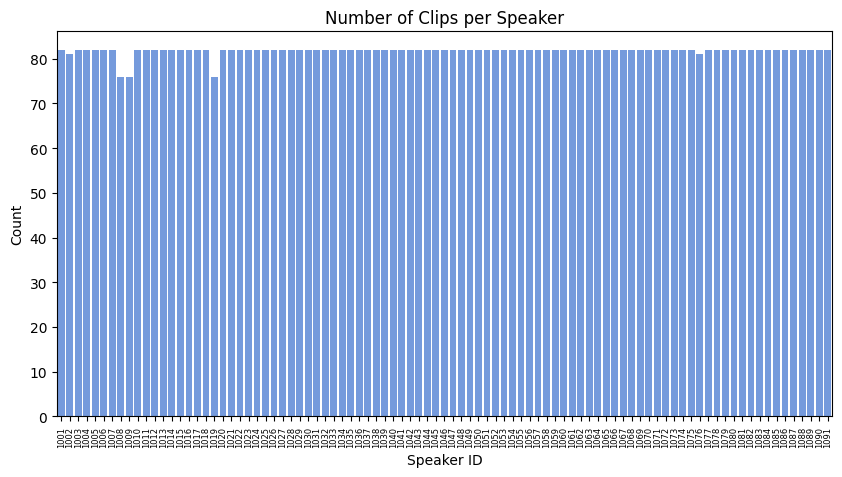

In [17]:
# 3. Speaker Distribution
speaker_counts = meta['speaker_id'].value_counts()
print(f"Total Speakers: {len(speaker_counts)}")
print(f"Min clips per speaker: {speaker_counts.min()}")
print(f"Max clips per speaker: {speaker_counts.max()}")

plt.figure(figsize=(10, 5))
sns.barplot(x=speaker_counts.index, y=speaker_counts.values, color='cornflowerblue')
plt.title("Number of Clips per Speaker")
plt.xlabel("Speaker ID")
plt.ylabel("Count")
plt.xticks(rotation=90, fontsize=6)
plt.show()

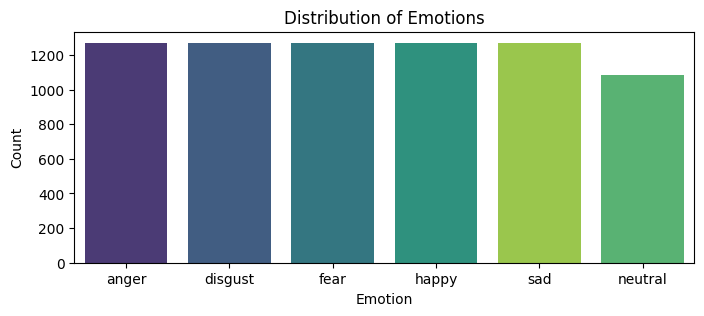

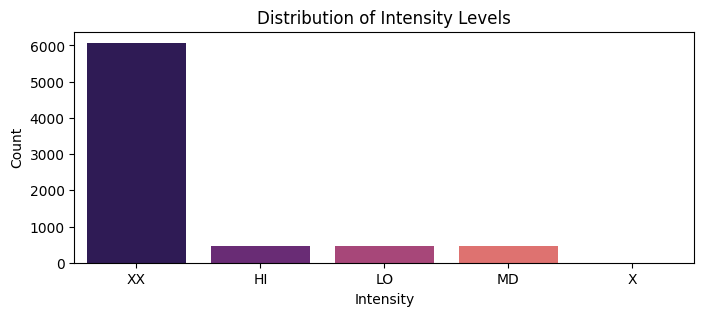

In [18]:
# 1. Emotion Distribution
plt.figure(figsize=(8, 3))
sns.countplot(data=meta, x='emotion', order=meta['emotion'].value_counts().index, palette='viridis', hue='emotion')
plt.title("Distribution of Emotions")
plt.xlabel("Emotion")
plt.ylabel("Count")
plt.show()

# 2. Intensity Distribution
plt.figure(figsize=(8, 3))
sns.countplot(data=meta, x='intensity', order=meta['intensity'].value_counts().index, palette='magma', hue='intensity')
plt.title("Distribution of Intensity Levels")
plt.xlabel("Intensity")
plt.ylabel("Count")
plt.show()

### Quantitative Analysis of Audio Features

Analyzing specific audio characteristics to see if they differentiate the emotions.

1.  **Duration Analysis**: Checking if the length of the audio clips varies by emotion or speaker. This informs decisions on padding/truncation ensuring model input consistency.
2.  **Energy (RMS)**: Root Mean Square energy is a proxy for loudness. We hypothesize that 'Anger' might have higher energy than 'Sadness'.
3.  **Zero Crossing Rate (ZCR)**: The rate at which the signal changes sign. High ZCR often correlates with noisy or high-frequency signals.



Audio Audio Feature Extraction: Iterating through the dataset and calculate Duration, RMS Energy (loudness), and Zero Crossing Rate (ZCR) (pitch/noise character) for every file.

In [19]:
# Calculate duration, RMS, and ZCR for all files
# (This might take a minute or two for the whole dataset)

durations = []
rms_means = []
zcr_means = []

print(f"Extracting features for {len(meta)} files...")

for i, row in meta.iterrows():
    if (i+1) % 1000 == 0:
        print(f"Processing {i+1}/{len(meta)}")
        
    y, sr = librosa.load(row['filepath'], sr=None)
    
    # Duration
    durations.append(librosa.get_duration(y=y, sr=sr))
    
    # RMS (Energy)
    rms = librosa.feature.rms(y=y)
    rms_means.append(np.mean(rms))
    
    # Zero Crossing Rate
    zcr = librosa.feature.zero_crossing_rate(y)
    zcr_means.append(np.mean(zcr))

# Add to dataframe
meta['duration'] = durations
meta['rms_mean'] = rms_means
meta['zcr_mean'] = zcr_means

print("Feature extraction complete.")
meta.head()

Extracting features for 7442 files...
Processing 1000/7442
Processing 2000/7442
Processing 3000/7442
Processing 4000/7442
Processing 5000/7442
Processing 6000/7442
Processing 7000/7442
Feature extraction complete.


,filepath,filename,speaker_id,utterance,emotion_code,emotion,intensity,duration,rms_mean,zcr_mean
0,/Users/victorhugogermano/Development/aai-540-f...,1001_DFA_ANG_XX.wav,1001,DFA,ANG,anger,XX,2.275562,0.041986,0.101868
1,/Users/victorhugogermano/Development/aai-540-f...,1001_DFA_DIS_XX.wav,1001,DFA,DIS,disgust,XX,2.335688,0.015996,0.093061
2,/Users/victorhugogermano/Development/aai-540-f...,1001_DFA_FEA_XX.wav,1001,DFA,FEA,fear,XX,2.168813,0.045776,0.084286
3,/Users/victorhugogermano/Development/aai-540-f...,1001_DFA_HAP_XX.wav,1001,DFA,HAP,happy,XX,1.868500,0.042300,0.084878
4,/Users/victorhugogermano/Development/aai-540-f...,1001_DFA_NEU_XX.wav,1001,DFA,NEU,neutral,XX,2.035375,0.020450,0.082031


Duration Visualization: Histograms and boxplots to see if certain emotions are naturally longer or shorter, and to get an idea of the average clip length 

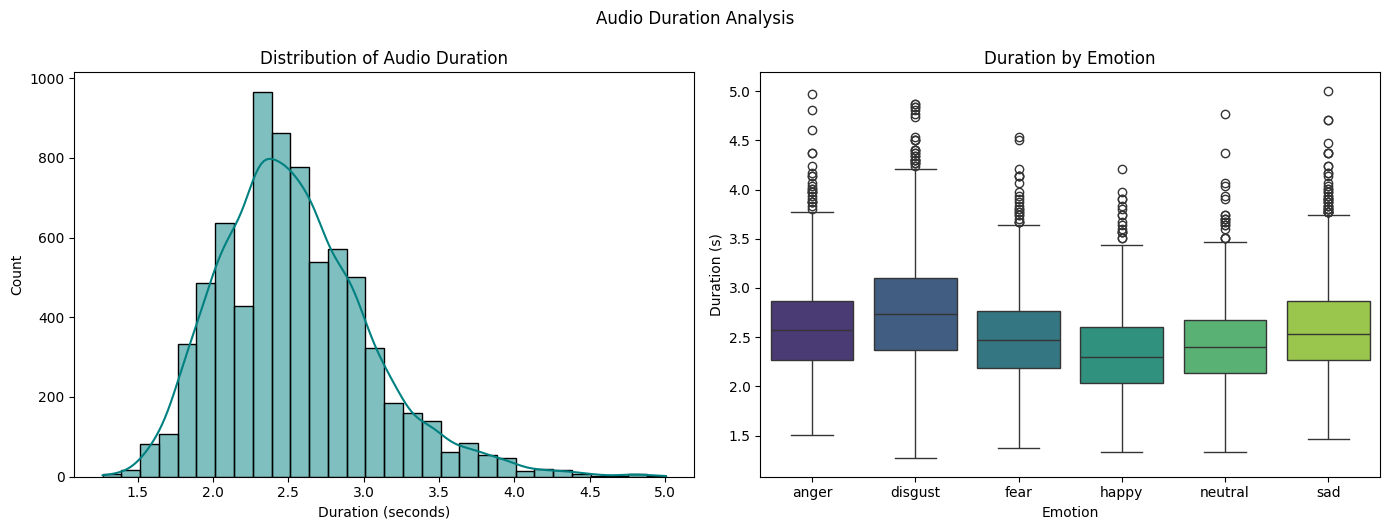

Mean duration: 2.54s
std duration: 0.51s


In [20]:
# Visualizing Duration
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.histplot(meta['duration'], bins=30, kde=True, color='teal')
plt.title("Distribution of Audio Duration")
plt.xlabel("Duration (seconds)")

plt.subplot(1, 2, 2)
sns.boxplot(x='emotion', y='duration', data=meta, palette='viridis', hue='emotion')
plt.title("Duration by Emotion")
plt.xlabel("Emotion")
plt.ylabel("Duration (s)")

plt.tight_layout()
plt.suptitle("Audio Duration Analysis", y=1.05)
plt.show()

print(f"Mean duration: {meta['duration'].mean():.2f}s")
print(f"std duration: {meta['duration'].std():.2f}s")

Acoustic Feature Visualization: Boxplots comparing RMS Energy and ZCR across different emotions to see if there are clear statistical distinctions (e.g., is "Anger" consistently louder?).

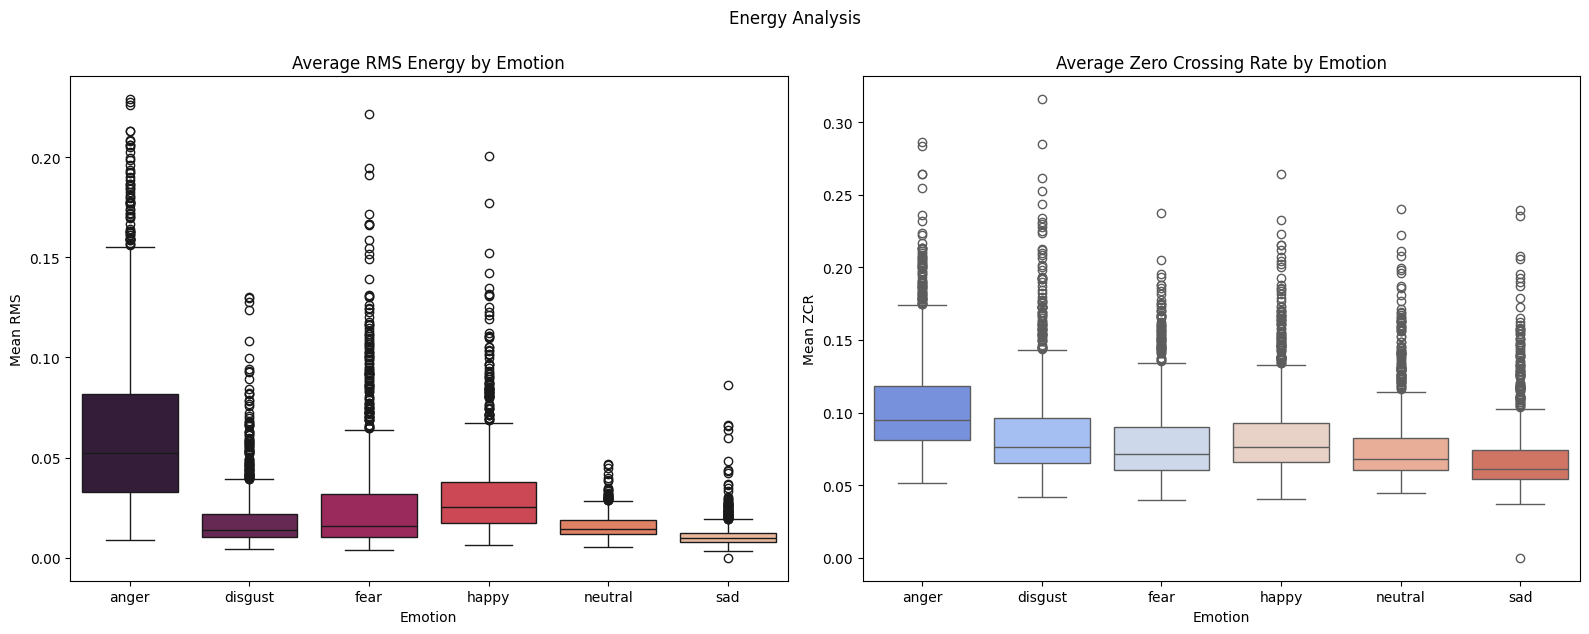

In [21]:
# Visualizing RMS and ZCR
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(x='emotion', y='rms_mean', data=meta, ax=axes[0], palette='rocket', hue='emotion')
axes[0].set_title("Average RMS Energy by Emotion")
axes[0].set_xlabel("Emotion")
axes[0].set_ylabel("Mean RMS")

sns.boxplot(x='emotion', y='zcr_mean', data=meta, ax=axes[1], palette='coolwarm', hue='emotion')
axes[1].set_title("Average Zero Crossing Rate by Emotion")
axes[1].set_xlabel("Emotion")
axes[1].set_ylabel("Mean ZCR")

plt.tight_layout()

plt.suptitle("Energy Analysis", y=1.05)
plt.show()

## Hipotesis - Emotions and Feature Patterns

- Anger: Higher RMS energy, pitch, spectral centroid
- Sadness: Lower energy, pitch, slower tempo
- Happy: Higher tempo, varied pitch, higher spectral centroid
- Fear: Higher pitch variability, irregular rhythm
- Neutral: Moderate values across features
- Disgust: Specific spectral patterns, lower pitch


In [ ]:
# Hypothesis Validation: Statistical Analysis of Audio Features by Emotion

import scipy.stats as stats
from scipy.stats import f_oneway
import warnings
warnings.filterwarnings('ignore')

# 1. Statistical Summary by Emotion
def analyze_feature_by_emotion(feature_name, hypothesis_description):
    """Analyze a specific feature across emotions with statistical tests"""
    print(f"\n{'='*60}")
    print(f"FEATURE: {feature_name.upper()}")
    print(f"HYPOTHESIS: {hypothesis_description}")
    print(f"{'='*60}")
    
    # Descriptive statistics
    stats_summary = meta.groupby('emotion')[feature_name].agg(['mean', 'std', 'median']).round(4)
    print("\nDescriptive Statistics:")
    print(stats_summary)
    
    # ANOVA test
    emotion_groups = [meta[meta['emotion'] == emotion][feature_name].values 
                     for emotion in meta['emotion'].unique()]
    f_stat, p_value = f_oneway(*emotion_groups)
    
    print(f"\nANOVA Test:")
    print(f"F-statistic: {f_stat:.4f}")
    print(f"P-value: {p_value:.6f}")
    print(f"Significant difference: {'YES' if p_value < 0.05 else 'NO'}")
    
    return stats_summary

# 2. Validate Each Hypothesis
print("VALIDATING EMOTION-FEATURE HYPOTHESES")
print("="*80)

# Anger: Higher RMS energy, pitch, spectral centroid
anger_rms = analyze_feature_by_emotion('rms_mean', 'Anger should have HIGHER RMS energy')
anger_pitch = analyze_feature_by_emotion('pitch_mean', 'Anger should have HIGHER pitch')
anger_centroid = analyze_feature_by_emotion('spectral_centroid_mean', 'Anger should have HIGHER spectral centroid')

# Sadness: Lower energy, pitch, slower tempo
sadness_rms = analyze_feature_by_emotion('rms_mean', 'Sadness should have LOWER energy')
sadness_pitch = analyze_feature_by_emotion('pitch_mean', 'Sadness should have LOWER pitch')
sadness_tempo = analyze_feature_by_emotion('tempo', 'Sadness should have SLOWER tempo')

# Happy: Higher tempo, varied pitch, higher spectral centroid
happy_tempo = analyze_feature_by_emotion('tempo', 'Happy should have HIGHER tempo')
happy_pitch_std = analyze_feature_by_emotion('pitch_std', 'Happy should have VARIED (higher std) pitch')
happy_centroid = analyze_feature_by_emotion('spectral_centroid_mean', 'Happy should have HIGHER spectral centroid')

# Fear: Higher pitch variability
fear_pitch_std = analyze_feature_by_emotion('pitch_std', 'Fear should have HIGHER pitch variability')
fear_pitch_range = analyze_feature_by_emotion('pitch_range', 'Fear should have HIGHER pitch range')

# Disgust: Lower pitch
disgust_pitch = analyze_feature_by_emotion('pitch_mean', 'Disgust should have LOWER pitch')

In [ ]:
# 3. Comprehensive Visualization of Hypotheses
fig, axes = plt.subplots(3, 3, figsize=(20, 15))
fig.suptitle('Emotion-Feature Hypothesis Validation', fontsize=16, y=0.98)

# Define features to analyze with their hypothesis
features_to_plot = [
    ('rms_mean', 'RMS Energy (Anger ↑, Sadness ↓)'),
    ('pitch_mean', 'Mean Pitch (Anger ↑, Sadness ↓, Disgust ↓)'),
    ('spectral_centroid_mean', 'Spectral Centroid (Anger ↑, Happy ↑)'),
    ('tempo', 'Tempo (Happy ↑, Sadness ↓)'),
    ('pitch_std', 'Pitch Variability (Happy ↑, Fear ↑)'),
    ('pitch_range', 'Pitch Range (Fear ↑)'),
    ('zcr_mean', 'Zero Crossing Rate'),
    ('spectral_bandwidth_mean', 'Spectral Bandwidth'),
    ('voicing_rate', 'Voicing Rate')
]

for idx, (feature, title) in enumerate(features_to_plot):
    row = idx // 3
    col = idx % 3
    
    sns.boxplot(x='emotion', y=feature, data=meta, ax=axes[row, col], 
                palette='Set2', hue='emotion', legend=False)
    axes[row, col].set_title(title, fontsize=12)
    axes[row, col].set_xlabel('Emotion')
    axes[row, col].set_ylabel(feature.replace('_', ' ').title())
    axes[row, col].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
# 4. Hypothesis Validation Summary Table
def validate_hypothesis_ranking(feature_name, expected_order):
    """Check if emotions rank as expected for a given feature"""
    actual_ranking = meta.groupby('emotion')[feature_name].mean().sort_values(ascending=False)
    
    print(f"\nFeature: {feature_name}")
    print(f"Expected high-to-low order: {expected_order}")
    print(f"Actual ranking (high-to-low):")
    for i, (emotion, value) in enumerate(actual_ranking.items()):
        print(f"  {i+1}. {emotion}: {value:.4f}")
    
    return actual_ranking

# Validate specific hypotheses
print("HYPOTHESIS VALIDATION SUMMARY")
print("="*50)

# Test key hypotheses
rms_ranking = validate_hypothesis_ranking('rms_mean', 
    "Anger > Happy/Fear > Neutral > Disgust > Sadness")

pitch_ranking = validate_hypothesis_ranking('pitch_mean', 
    "Anger > Happy/Fear > Neutral > Disgust/Sadness")

tempo_ranking = validate_hypothesis_ranking('tempo', 
    "Happy > Anger/Fear > Neutral > Disgust > Sadness")

centroid_ranking = validate_hypothesis_ranking('spectral_centroid_mean', 
    "Anger > Happy > Fear > Neutral > Disgust > Sadness")

pitch_variability_ranking = validate_hypothesis_ranking('pitch_std', 
    "Fear > Happy > Anger > Neutral > Disgust/Sadness")

In [ ]:
# 5. Correlation Analysis Between Features and Emotions
# Create a feature matrix for correlation analysis
feature_cols = ['rms_mean', 'pitch_mean', 'spectral_centroid_mean', 'tempo', 
                'pitch_std', 'pitch_range', 'zcr_mean', 'spectral_bandwidth_mean', 
                'voicing_rate', 'chroma_mean', 'spectral_contrast_mean']

# Create emotion dummies for correlation
emotion_dummies = pd.get_dummies(meta['emotion'], prefix='emotion')
correlation_df = pd.concat([meta[feature_cols], emotion_dummies], axis=1)

# Calculate correlations
correlation_matrix = correlation_df.corr()
emotion_feature_corr = correlation_matrix.loc[feature_cols, emotion_dummies.columns]

# Plot correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(emotion_feature_corr, annot=True, cmap='RdBu_r', center=0,
            fmt='.3f', square=True, cbar_kws={'shrink': 0.8})
plt.title('Feature-Emotion Correlations\n(Positive = Higher values for that emotion)', 
          fontsize=14, pad=20)
plt.xlabel('Emotions', fontsize=12)
plt.ylabel('Audio Features', fontsize=12)
plt.tight_layout()
plt.show()

# Print strongest correlations for each emotion
print("\nSTRONGEST FEATURE CORRELATIONS BY EMOTION:")
print("="*50)
for emotion_col in emotion_dummies.columns:
    emotion = emotion_col.replace('emotion_', '')
    correlations = emotion_feature_corr[emotion_col].abs().sort_values(ascending=False)
    print(f"\n{emotion.upper()}:")
    for feature, corr in correlations.head(3).items():
        direction = "↑" if emotion_feature_corr.loc[feature, emotion_col] > 0 else "↓"
        print(f"  {feature}: {emotion_feature_corr.loc[feature, emotion_col]:+.3f} {direction}")

In [ ]:
# 6. Statistical Significance Testing (Pairwise comparisons)
from scipy.stats import ttest_ind

def test_emotion_pairs(feature_name, emotion1, emotion2):
    """Test if two emotions differ significantly on a feature"""
    group1 = meta[meta['emotion'] == emotion1][feature_name].dropna()
    group2 = meta[meta['emotion'] == emotion2][feature_name].dropna()
    
    t_stat, p_value = ttest_ind(group1, group2)
    
    mean1 = group1.mean()
    mean2 = group2.mean()
    
    return {
        'feature': feature_name,
        'emotion1': emotion1,
        'emotion2': emotion2,
        'mean1': mean1,
        'mean2': mean2,
        'difference': mean1 - mean2,
        't_stat': t_stat,
        'p_value': p_value,
        'significant': p_value < 0.05
    }

# Test key hypothesis comparisons
print("\nPAIRWISE STATISTICAL TESTS:")
print("="*60)

key_tests = [
    ('rms_mean', 'anger', 'sadness'),
    ('pitch_mean', 'anger', 'sadness'),
    ('tempo', 'happy', 'sadness'),
    ('spectral_centroid_mean', 'anger', 'sadness'),
    ('pitch_std', 'fear', 'neutral'),
    ('pitch_mean', 'disgust', 'anger')
]

for feature, emo1, emo2 in key_tests:
    result = test_emotion_pairs(feature, emo1, emo2)
    print(f"\n{feature.upper()}: {emo1.upper()} vs {emo2.upper()}")
    print(f"  {emo1}: {result['mean1']:.4f}")
    print(f"  {emo2}: {result['mean2']:.4f}")
    print(f"  Difference: {result['difference']:+.4f}")
    print(f"  P-value: {result['p_value']:.6f}")
    print(f"  Significant: {'✓' if result['significant'] else '✗'}")

1. Statistical Summary: Provide descriptive statistics and ANOVA tests for each feature across emotions
2. Visualization: Create boxplots to visually validate hypotheses
3. Ranking Validation: Check if emotions rank as expected for each feature
4. Correlation Analysis: Show which features are most strongly associated with each emotion
5. Pairwise Testing: Test specific emotion pairs to validate key hypotheses

---

# Extracting Features and Athena Database

